In [1]:
#Importamos las librerias a usar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
#Cargamos el dataseet
df = pd.read_csv('dataset/smart_workout_raw_dataset.csv')

In [3]:
# ver las primeras 5 columnas
df.head()

,user_id,user_name,persona,age,fitness_goal,experience_level,injury_constraint,exercise_id,exercise_name,bodyPart,equipment,target_muscle,rating,bodyPart_icon,equipment_icon,persona_icon,injury_icon
0,U0363,Emily Rivera,low_stress,53.0,FAT_LOSS,intermediate,shoulder_injury,1679,dumbbell seated one arm bicep curl on exercise...,upper arms,dumbbell,biceps,2.0,💪,🏋️,🟢,🤕
1,U0280,Aiden Perez,high_stress_low_support,46.0,mobility,intermediate,none,1338,exercise ball hug,back,stability ball,spine,5.0,🏋️,🏐,🔴,✅
2,U0043,Emma Lopez,moderate_stress,21.0,endurance,intermediate,none,10,assisted hanging knee raise with throw down,waist,assisted,abs,3.0,🧘,🤝,🟡,✅
3,U0007,Ashley Campbell,high_stress_low_support,56.0,mobility,advanced,knee_pain,2805,dumbbell single leg deadlift with stepbox support,upper legs,dumbbell,glutes,3.0,🦵,🏋️,🔴,🦵⚠️
4,U0187,Mia Nelson,low_stress,35.0,muscle_gain,beginner,none,1018,band shrug,back,band,traps,3.0,🏋️,➰,🟢,✅


In [4]:
# Ver el numero de columnas y filas

df.shape

(11165, 17)

In [5]:
#Ver la informacion completa del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11165 entries, 0 to 11164
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            11165 non-null  str    
 1   user_name          11165 non-null  str    
 2   persona            11165 non-null  str    
 3   age                10826 non-null  float64
 4   fitness_goal       11165 non-null  str    
 5   experience_level   11165 non-null  str    
 6   injury_constraint  10944 non-null  str    
 7   exercise_id        11165 non-null  int64  
 8   exercise_name      11165 non-null  str    
 9   bodyPart           11165 non-null  str    
 10  equipment          10947 non-null  str    
 11  target_muscle      10999 non-null  str    
 12  rating             11165 non-null  float64
 13  bodyPart_icon      11165 non-null  str    
 14  equipment_icon     11165 non-null  str    
 15  persona_icon       11165 non-null  str    
 16  injury_icon        11165 non-null

In [6]:
# Ver los valores nulos

df.isnull().sum()

user_id                0
user_name              0
persona                0
age                  339
fitness_goal           0
experience_level       0
injury_constraint    221
exercise_id            0
exercise_name          0
bodyPart               0
equipment            218
target_muscle        166
rating                 0
bodyPart_icon          0
equipment_icon         0
persona_icon           0
injury_icon            0
dtype: int64

In [7]:
#Ver los valores duplicados

df.duplicated().sum()

np.int64(105)

In [8]:
#Ver las variables numericas

df.describe()

,age,exercise_id,rating
count,10826.000000,11165.000000,11165.000000
mean,38.210142,1202.430990,3.806099
std,20.405005,1006.000265,1.038170
min,-5.000000,1.000000,-1.400000
25%,27.000000,386.000000,3.000000
50%,38.000000,873.000000,4.000000
75%,49.000000,1666.000000,5.000000
max,999.000000,5201.000000,6.300000


In [9]:
df.nunique().sort_values()

persona                 3
persona_icon            3
injury_constraint       4
injury_icon             4
bodyPart_icon           9
experience_level       12
equipment_icon         14
target_muscle          19
fitness_goal           20
rating                 21
bodyPart               37
age                    48
equipment              81
user_name             500
user_id               500
exercise_name        1322
exercise_id          1327
dtype: int64

In [10]:
sorted(df['rating'].unique())

[np.float64(-1.4),
 np.float64(-1.1),
 np.float64(-0.7),
 np.float64(-0.3),
 np.float64(-0.2),
 np.float64(-0.1),
 np.float64(0.3),
 np.float64(0.4),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(5.2),
 np.float64(5.3),
 np.float64(5.4),
 np.float64(5.5),
 np.float64(5.6),
 np.float64(6.1),
 np.float64(6.2),
 np.float64(6.3)]

In [11]:
df['rating'].describe()

count    11165.000000
mean         3.806099
std          1.038170
min         -1.400000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.300000
Name: rating, dtype: float64

In [12]:
# Analizamos la variable objetivo

df['rating'].value_counts()

rating
 4.0    3764
 5.0    3336
 3.0    2895
 2.0     871
 1.0     279
-0.1       2
-0.7       2
 5.3       2
 6.1       2
 5.5       1
 5.4       1
-0.2       1
 5.6       1
 0.4       1
 6.2       1
-0.3       1
 6.3       1
-1.1       1
 5.2       1
 0.3       1
-1.4       1
Name: count, dtype: int64

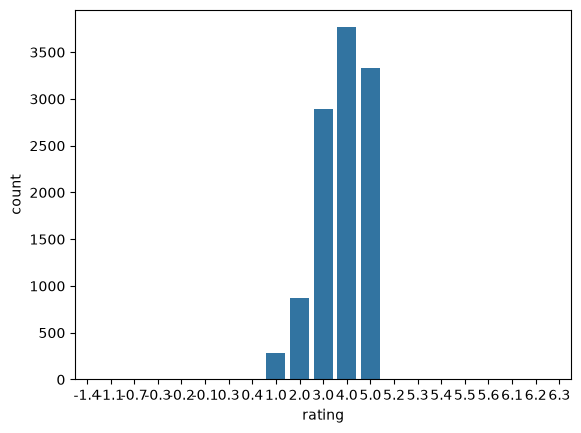

In [13]:
sns.countplot(x='rating', data=df)
plt.show()

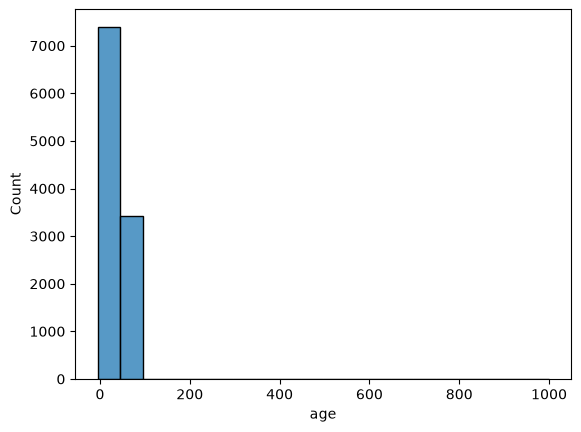

In [14]:
# Exploramos la edad
sns.histplot(df['age'], bins=20)
plt.show()

In [15]:
#Analizar la columna fitness goal
df['fitness_goal'].value_counts()

fitness_goal
endurance              2253
mobility               2247
fat_loss               2111
general_fitness        2018
muscle_gain            1978
  mobility               50
  endurance              43
ENDURANCE                43
General_Fitness          41
Fat_Loss                 41
Endurance                40
Mobility                 39
FAT_LOSS                 36
  muscle_gain            36
MUSCLE_GAIN              34
GENERAL_FITNESS          34
Muscle_Gain              33
  general_fitness        32
MOBILITY                 32
  fat_loss               24
Name: count, dtype: int64

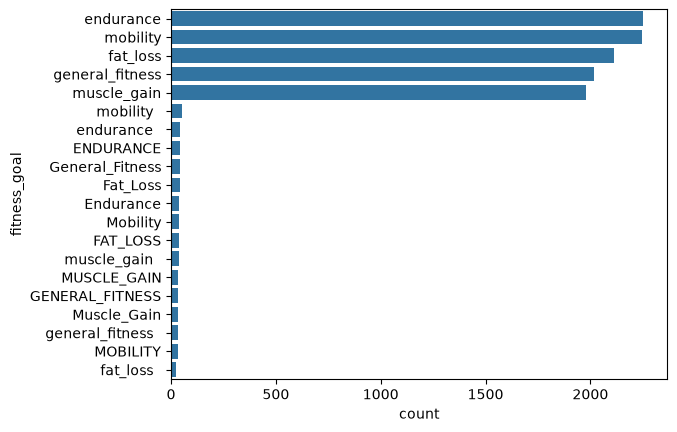

In [16]:
sns.countplot(
    y=df['fitness_goal'],
    order=df['fitness_goal'].value_counts().index
)
plt.show()

In [17]:
#Analisamos el nivel de experiencia

df['experience_level'].value_counts()

experience_level
beginner            5412
intermediate        3406
advanced            1789
  beginner           102
BEGINNER              92
Beginner              88
  intermediate        68
Intermediate          63
INTERMEDIATE          56
Advanced              31
  advanced            30
ADVANCED              28
Name: count, dtype: int64

In [18]:
#Analizamos las lesiones

df['injury_constraint'].value_counts()

injury_constraint
none               6985
knee_pain          1392
back_pain          1364
shoulder_injury    1203
Name: count, dtype: int64

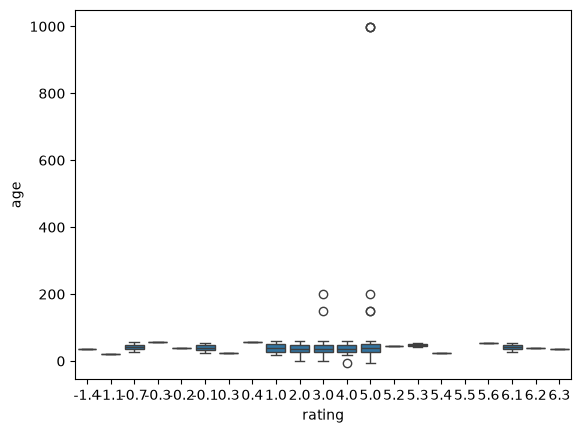

In [19]:
#Observamos la relacion con el rating

sns.boxplot(
    x='rating',
    y='age',
    data=df
)
plt.show()

In [20]:
#Analizamos la columnas Age para revisar estas columnas

df['age'].describe()

count    10826.000000
mean        38.210142
std         20.405005
min         -5.000000
25%         27.000000
50%         38.000000
75%         49.000000
max        999.000000
Name: age, dtype: float64

In [21]:
df.sort_values('age', ascending=False)[['age', 'rating']].head(20)

,age,rating
1622,999.0,5.0
1774,999.0,5.0
4535,999.0,5.0
6236,200.0,3.0
1159,200.0,5.0
8159,150.0,5.0
4640,150.0,5.0
10540,150.0,3.0
3207,59.0,3.0
3217,59.0,4.0


In [22]:
print(df['rating'].min())
print(df['rating'].max())

-1.4
6.3


In [23]:
df['rating'].describe()

count    11165.000000
mean         3.806099
std          1.038170
min         -1.400000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.300000
Name: rating, dtype: float64